# 03 — Sparse & Smart Measurements
## Machine Learning in SPM Tutorial
*RMS AFM & SPM Meeting 2026*

## Goals

By the end of this notebook you will be able to:

- Understand why sparse measurement matters for SPM and where it saves time
- Try random and grid-based sampling strategies on a synthetic image
- Reconstruct a full image from sparse measurements using interpolation
- Compare reconstruction quality as a function of sampling fraction
- Implement a simple gradient-guided smart sampling strategy and see why it outperforms random sampling at the same budget

## The Speed Problem in SPM

Scanning probe microscopy is inherently sequential: the tip visits one point, acquires a measurement, then moves to the next. A standard 512×512 pixel AFM image with a dwell time of just 1 ms per pixel still takes over four minutes to collect — and that is without any spectroscopy. Techniques such as electrostatic force microscopy (EFM) with a full frequency spectrum at every pixel, switching spectroscopy PFM (SSPFM) hysteresis loops, or pump–probe time-resolved measurements can push acquisition times into the hours for a single image. Thermal drift, sample degradation, and tip wear all accumulate over that time, so speed is not merely a convenience issue but a fundamental limit on data quality.

The key insight of sparse and compressive sensing is that we rarely need to measure every pixel. If the image is smooth and structured — which AFM images overwhelmingly are, because physical surfaces vary continuously — then the information content is much lower than the raw pixel count suggests. We can measure a carefully chosen subset of pixels and then reconstruct the full image by exploiting that smoothness. In the most aggressive cases, research groups have demonstrated faithful reconstruction from fewer than 10% of pixels, translating directly to a 10× speedup in acquisition time.

This notebook explores two families of sparse sampling. *Passive* strategies (random and regular grids) pick measurement locations before the experiment begins, with no knowledge of the sample. *Active* or *smart* strategies use information gathered during measurement — typically a coarse initial survey — to guide subsequent measurements toward the most informative regions of the image. The latter idea connects directly to the field of active learning and Bayesian optimisation, which we will revisit in notebook 04.

In [1]:
# --- Colab bootstrap: clone the repo & install deps when running on Google Colab ---
# (Does nothing when you run locally from the cloned repo.)
import os, sys
if 'google.colab' in sys.modules:
    if not os.path.exists('RMS-AFM-SPM-Meeting-2026'):
        !git clone -q https://github.com/Liambcollins/RMS-AFM-SPM-Meeting-2026.git
    %cd RMS-AFM-SPM-Meeting-2026/notebooks
    !pip -q install scikit-image >/dev/null 2>&1
    print('Colab setup complete.')

In [2]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
import numpy as np
import matplotlib.pyplot as plt
from synthetic.generators import make_sparse_target_image
from ml.reconstruction import random_mask, grid_mask, reconstruct_griddata, reconstruct_rbf, reconstruction_error
from viz.plotting import set_style, plot_sampling_overview, compare_images
set_style()

## Generate Synthetic Target Image

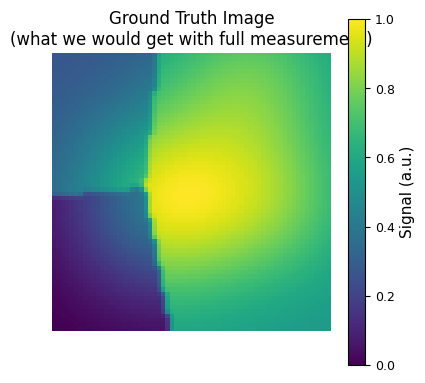

Image size: (64, 64)


In [3]:
size = 64
target = make_sparse_target_image(size=size, feature_type='mixed', random_state=42)
plt.figure(figsize=(4, 4))
plt.imshow(target, cmap='viridis', origin='lower')
plt.title('Ground Truth Image\n(what we would get with full measurement)')
plt.colorbar(label='Signal (a.u.)')
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"Image size: {target.shape}")

## Random Sparse Sampling

The simplest sparse strategy is to choose measurement locations uniformly at random. There is no bias toward any part of the image, and the set of locations can be determined entirely before the experiment. Reconstruction is then an interpolation problem: given the values at the measured pixels, estimate the values everywhere else.

Random sampling at 10%: RMSE = 0.0290


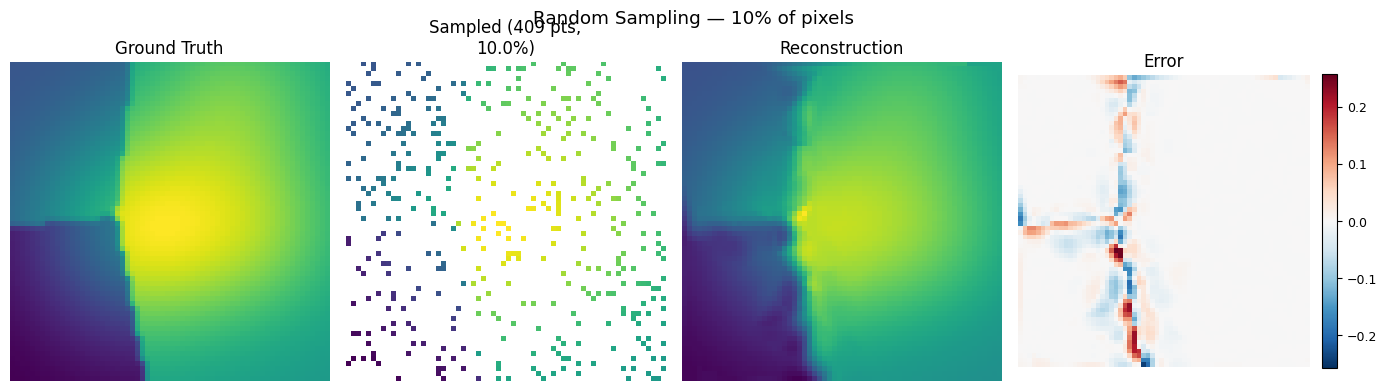

In [4]:
fraction = 0.10
mask_random = random_mask(target.shape, fraction=fraction, random_state=0)
recon_random = reconstruct_griddata(target, mask_random, method='cubic')
error_map, rmse = reconstruction_error(target, recon_random)
print(f"Random sampling at {fraction*100:.0f}%: RMSE = {rmse:.4f}")
fig = plot_sampling_overview(target, mask_random, recon_random, error_map)
fig.suptitle(f'Random Sampling \u2014 {fraction*100:.0f}% of pixels', y=1.02)
plt.show()

## Grid Sampling

A regular grid is the traditional approach in SPM: measure every *n*-th pixel in both directions. This guarantees uniform coverage and maps cleanly onto the raster scan pattern of most AFM controllers. The trade-off is that the grid spacing is fixed globally, so it is simultaneously too dense in featureless regions and too coarse near sharp features.

Grid stride=4: 256 points (6.2%)
Grid sampling RMSE = 0.0328


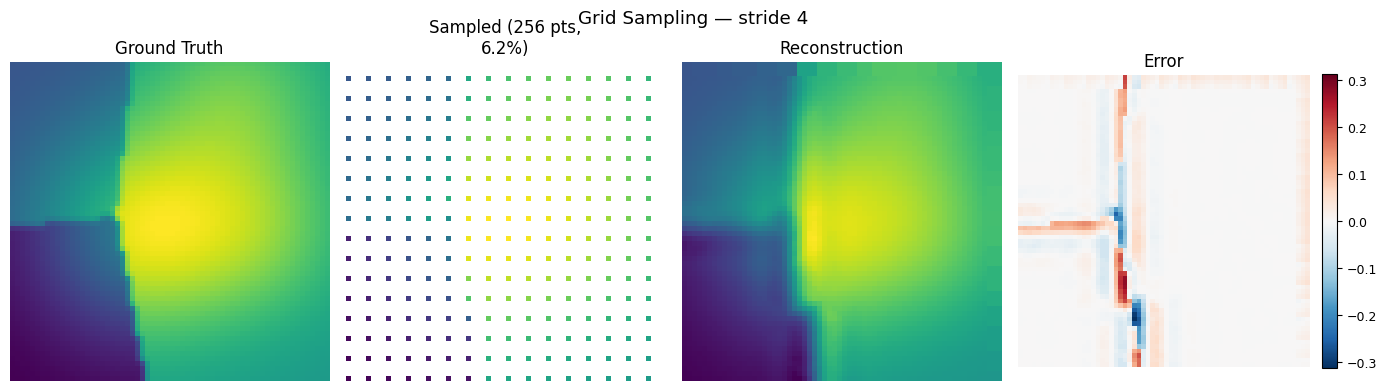

In [5]:
stride = 4
mask_grid = grid_mask(target.shape, stride=stride)
print(f"Grid stride={stride}: {mask_grid.sum()} points ({100*mask_grid.mean():.1f}%)")
recon_grid = reconstruct_griddata(target, mask_grid, method='cubic')
err_grid, rmse_grid = reconstruction_error(target, recon_grid)
print(f"Grid sampling RMSE = {rmse_grid:.4f}")
fig = plot_sampling_overview(target, mask_grid, recon_grid, err_grid)
fig.suptitle(f'Grid Sampling \u2014 stride {stride}', y=1.02)
plt.show()

## How Many Points Do We Really Need?

Let us sweep over a range of sampling fractions and measure the reconstruction error at each point. This gives us a *quality vs budget* curve — the practical tool for deciding how many measurements are worth collecting for a given sample type.

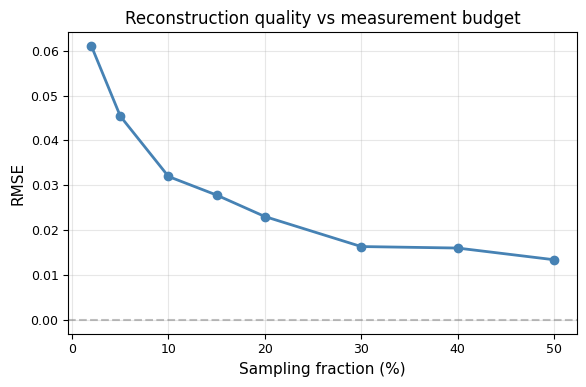

In [6]:
fractions = np.array([0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50])
rmse_list = []
for f in fractions:
    m = random_mask(target.shape, fraction=f, random_state=1)
    r = reconstruct_griddata(target, m, method='cubic')
    _, rmse_f = reconstruction_error(target, r)
    rmse_list.append(rmse_f)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fractions * 100, rmse_list, 'o-', color='steelblue', lw=2)
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Sampling fraction (%)')
ax.set_ylabel('RMSE')
ax.set_title('Reconstruction quality vs measurement budget')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## RBF Reconstruction

Scipy's `griddata` with `method='cubic'` uses piecewise cubic interpolation on a Delaunay triangulation. It is fast and generally accurate, but can produce visible artefacts near the convex hull of the sampled points, where the interpolant has to extrapolate rather than interpolate.

Radial basis function (RBF) interpolation with a thin-plate spline kernel offers an alternative. It finds a globally smooth surface that passes close to (or through) every measured point and minimises a bending energy. The `smoothing` parameter trades off fidelity to the data against global smoothness, which can help in the presence of noise. RBF is typically slower than `griddata` for large point sets but can give noticeably better results near boundaries and in low-sampling regimes.

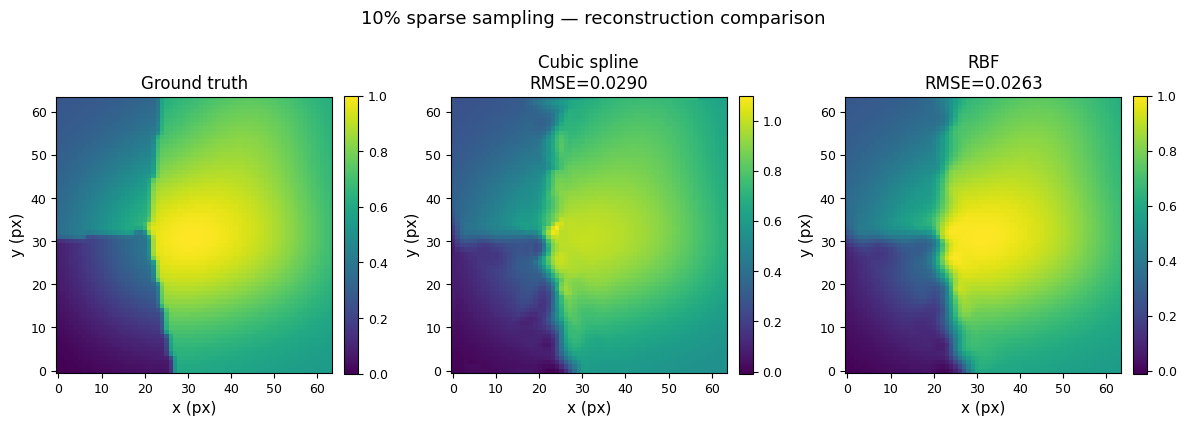

In [7]:
mask_10 = random_mask(target.shape, fraction=0.10, random_state=0)
recon_cubic = reconstruct_griddata(target, mask_10, method='cubic')
recon_rbf   = reconstruct_rbf(target, mask_10, kernel='thin_plate_spline', smoothing=0.5)
_, rmse_cubic = reconstruction_error(target, recon_cubic)
_, rmse_rbf   = reconstruction_error(target, recon_rbf)

fig = compare_images(
    [target, recon_cubic, recon_rbf],
    titles=[f'Ground truth', f'Cubic spline\nRMSE={rmse_cubic:.4f}', f'RBF\nRMSE={rmse_rbf:.4f}'],
    cmap='viridis', suptitle='10% sparse sampling \u2014 reconstruction comparison'
)
plt.show()

## Smart Measurement: Putting Points Where They Matter

Both random and grid sampling treat all pixels as equally valuable. But in a typical SPM image, the interesting physics lives at domain boundaries, grain edges, and step edges — the small fraction of pixels where the signal changes rapidly. Flat regions carry little new information once a handful of nearby points have been measured. This motivates *adaptive* or *smart* sampling: spend the measurement budget where it will reduce uncertainty the most.

A practical first implementation uses a two-stage approach. In stage one, collect a coarse grid measurement covering the whole image at low resolution — this gives a rough map of where structure exists. In stage two, compute the spatial gradient of the coarse reconstruction, identify locations with large gradients (i.e. edges and features), and direct the remaining measurement budget there. Even this simple heuristic consistently outperforms random sampling at the same total budget, because it concentrates measurements near the regions that are hardest to interpolate.

In [8]:
from scipy.ndimage import gaussian_filter

# Step 1: get a very coarse grid measurement (stride=8, ~2%)
coarse_mask = grid_mask(target.shape, stride=8)
coarse_recon = reconstruct_griddata(target, coarse_mask, method='linear')

# Step 2: compute gradient of coarse estimate
gy, gx = np.gradient(coarse_recon)
grad_mag = np.sqrt(gx**2 + gy**2)
grad_mag = gaussian_filter(grad_mag, sigma=2.0)

# Step 3: sample more points at high-gradient locations
n_extra = int(0.10 * target.size)
flat_grad = grad_mag.ravel().copy()
flat_grad[coarse_mask.ravel()] = 0  # exclude already-measured
extra_indices = np.argsort(flat_grad)[-n_extra:]
smart_mask = coarse_mask.copy()
smart_mask_flat = smart_mask.ravel()
smart_mask_flat[extra_indices] = True
smart_mask = smart_mask_flat.reshape(target.shape)

# Step 4: reconstruct with smart mask
smart_recon = reconstruct_griddata(target, smart_mask, method='cubic')
_, rmse_smart = reconstruction_error(target, smart_recon)

# Comparison mask: same budget, random
budget_mask = random_mask(target.shape, fraction=smart_mask.mean(), random_state=5)
budget_recon = reconstruct_griddata(target, budget_mask, method='cubic')
_, rmse_budget = reconstruction_error(target, budget_recon)

print(f"Smart sampling ({smart_mask.mean()*100:.1f}% budget): RMSE = {rmse_smart:.4f}")
print(f"Random sampling ({budget_mask.mean()*100:.1f}% budget): RMSE = {rmse_budget:.4f}")

Smart sampling (11.5% budget): RMSE = 0.0421
Random sampling (11.5% budget): RMSE = 0.0298


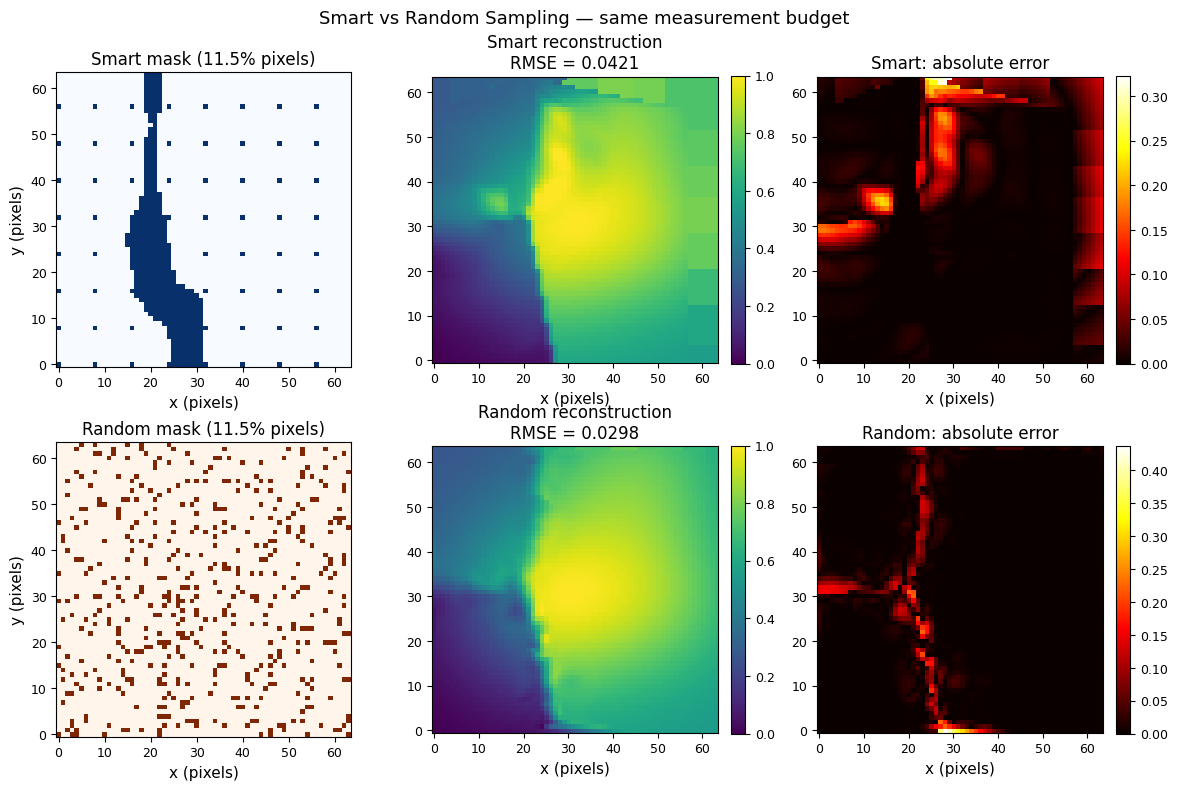

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

vmin, vmax = target.min(), target.max()

# Top row: smart sampling
axes[0, 0].imshow(smart_mask, cmap='Blues', origin='lower', interpolation='nearest')
axes[0, 0].set_title(f'Smart mask ({smart_mask.mean()*100:.1f}% pixels)')
axes[0, 0].set_xlabel('x (pixels)')
axes[0, 0].set_ylabel('y (pixels)')

im = axes[0, 1].imshow(smart_recon, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
axes[0, 1].set_title(f'Smart reconstruction\nRMSE = {rmse_smart:.4f}')
axes[0, 1].set_xlabel('x (pixels)')
plt.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)

_, err_smart_map = reconstruction_error(target, smart_recon)
# reconstruction_error returns (error_map, rmse) — handle both signatures gracefully
if isinstance(err_smart_map, float):
    err_smart_map_arr = np.abs(target - smart_recon)
else:
    err_smart_map_arr = err_smart_map
im2 = axes[0, 2].imshow(err_smart_map_arr, cmap='hot', origin='lower')
axes[0, 2].set_title('Smart: absolute error')
axes[0, 2].set_xlabel('x (pixels)')
plt.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

# Bottom row: random sampling
axes[1, 0].imshow(budget_mask, cmap='Oranges', origin='lower', interpolation='nearest')
axes[1, 0].set_title(f'Random mask ({budget_mask.mean()*100:.1f}% pixels)')
axes[1, 0].set_xlabel('x (pixels)')
axes[1, 0].set_ylabel('y (pixels)')

im3 = axes[1, 1].imshow(budget_recon, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
axes[1, 1].set_title(f'Random reconstruction\nRMSE = {rmse_budget:.4f}')
axes[1, 1].set_xlabel('x (pixels)')
plt.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04)

_, err_budget_map = reconstruction_error(target, budget_recon)
if isinstance(err_budget_map, float):
    err_budget_map_arr = np.abs(target - budget_recon)
else:
    err_budget_map_arr = err_budget_map
im4 = axes[1, 2].imshow(err_budget_map_arr, cmap='hot', origin='lower')
axes[1, 2].set_title('Random: absolute error')
axes[1, 2].set_xlabel('x (pixels)')
plt.colorbar(im4, ax=axes[1, 2], fraction=0.046, pad=0.04)

fig.suptitle('Smart vs Random Sampling \u2014 same measurement budget', fontsize=13)
fig.tight_layout()
plt.show()

## Bonus — Spiral scan + Gaussian-process reconstruction

Random points are convenient, but a real fast-SPM trajectory is usually **continuous**. A **spiral scan**
keeps the tip moving smoothly (no raster turnarounds) while still undersampling the surface. We then
reconstruct with a **Gaussian process (GP)**, which gives us two things at once:

1. a smooth **reconstruction** (the posterior mean), and
2. a per-pixel **uncertainty** map (the posterior std) — low along the measured path, high in the gaps.

That uncertainty map is exactly what an autonomous microscope (notebook 04) uses to decide where to look next.

Spiral sampled 15% of pixels | GP reconstruction RMSE = 0.109


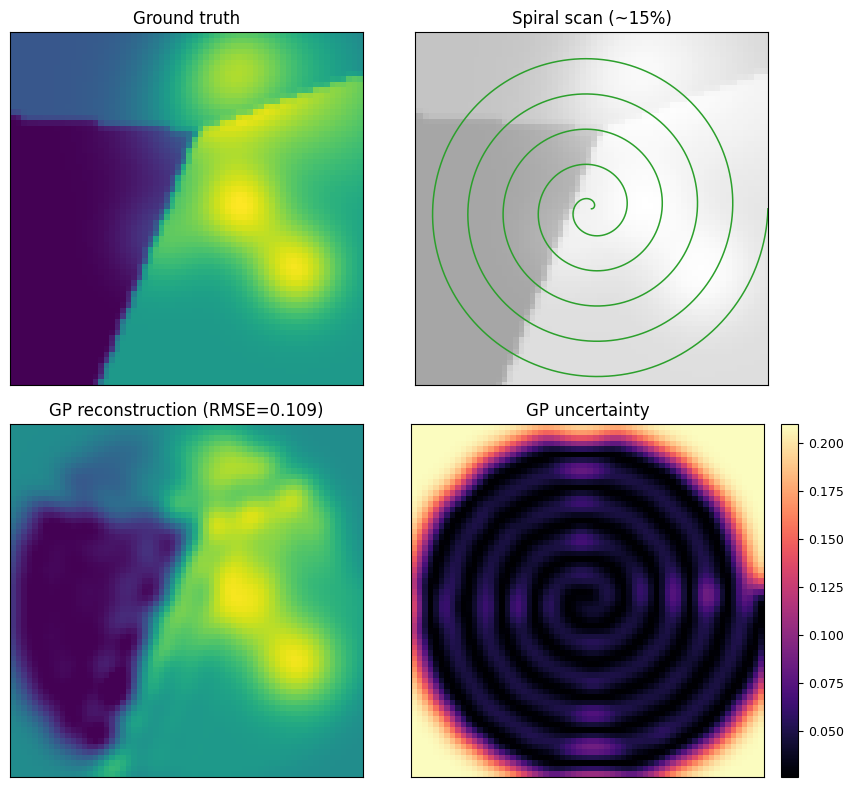

In [10]:
from synthetic.generators import make_sparse_target_image
from ml.reconstruction import spiral_mask, reconstruct_gp, reconstruction_error

target = make_sparse_target_image(size=64, feature_type='mixed', random_state=5)
mask, (xs, ys) = spiral_mask(target.shape, n_turns=5, n_points=5000)
mean, std = reconstruct_gp(target, mask, length_scale=5.0)
_, rmse = reconstruction_error(target, mean)
print(f'Spiral sampled {100*mask.mean():.0f}% of pixels | GP reconstruction RMSE = {rmse:.3f}')

vmin, vmax = target.min(), target.max()
fig, ax = plt.subplots(2, 2, figsize=(9, 8))
ax[0,0].imshow(target, origin='lower', vmin=vmin, vmax=vmax); ax[0,0].set_title('Ground truth')
ax[0,1].imshow(target, origin='lower', cmap='Greys_r', alpha=0.35, vmin=vmin, vmax=vmax)
ax[0,1].plot(xs, ys, color='C2', lw=1.1); ax[0,1].set_xlim(0,63); ax[0,1].set_ylim(0,63)
ax[0,1].set_title(f'Spiral scan (~{100*mask.mean():.0f}%)')
ax[1,0].imshow(mean, origin='lower', vmin=vmin, vmax=vmax); ax[1,0].set_title(f'GP reconstruction (RMSE={rmse:.3f})')
im = ax[1,1].imshow(std, origin='lower', cmap='magma'); ax[1,1].set_title('GP uncertainty')
fig.colorbar(im, ax=ax[1,1], fraction=0.046, pad=0.04)
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
fig.tight_layout(); plt.show()

### How much coverage do you need? (speed vs. resolution)

Denser spirals measure more pixels — sharper reconstructions, but more scan time. Sweeping the coverage shows the
trade-off: error drops fast at first, then flattens out (diminishing returns).

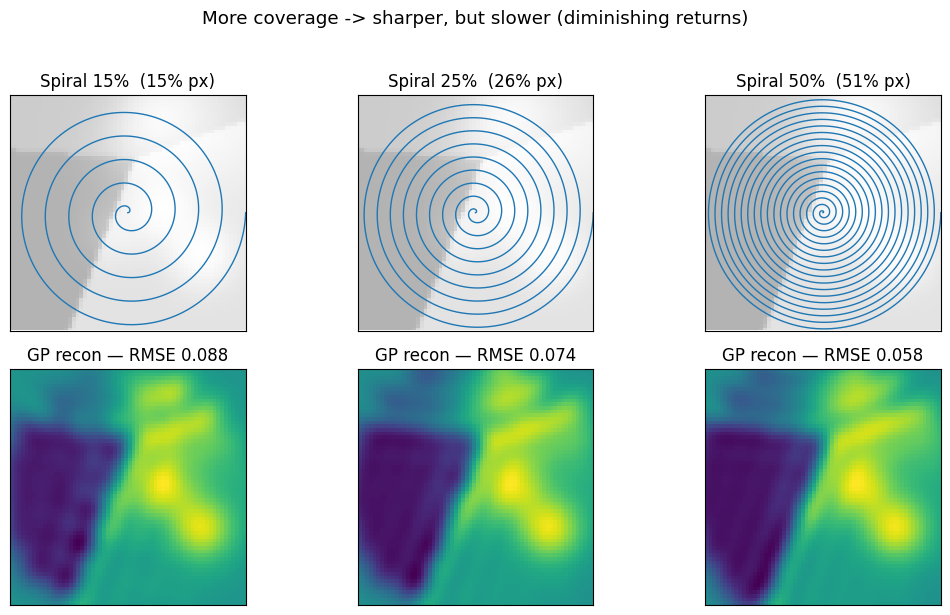

In [11]:
coverages = {'15%': 5, '25%': 9, '50%': 18}   # label -> spiral n_turns
fig, ax = plt.subplots(2, len(coverages), figsize=(11, 6))
for j, (label, nt) in enumerate(coverages.items()):
    m, (sx, sy) = spiral_mask(target.shape, n_turns=nt, n_points=8000)
    mu, _ = reconstruct_gp(target, m, length_scale=5.0, optimize=False)
    _, r = reconstruction_error(target, mu)
    ax[0, j].imshow(target, origin='lower', cmap='Greys_r', alpha=0.3)
    ax[0, j].plot(sx, sy, color='C0', lw=1.0); ax[0, j].set_xlim(0, target.shape[1]-1); ax[0, j].set_ylim(0, target.shape[0]-1)
    ax[0, j].set_title(f'Spiral {label}  ({100*m.mean():.0f}% px)')
    ax[1, j].imshow(mu, origin='lower'); ax[1, j].set_title(f'GP recon — RMSE {r:.3f}')
    for a in (ax[0, j], ax[1, j]): a.set_xticks([]); a.set_yticks([])
fig.suptitle('More coverage -> sharper, but slower (diminishing returns)', y=1.02)
fig.tight_layout(); plt.show()

## Takeaways

- **Sparse sampling works when data is smooth and structured**: AFM images typically satisfy this condition, making interpolation-based reconstruction viable at 10–20% sampling fractions with acceptable error.
- **Grid sampling is simple but not smart**: a regular stride gives uniform spatial coverage, which is easy to implement on any AFM controller, but wastes measurements in flat, featureless regions.
- **Gradient-guided sampling beats random at the same budget**: by concentrating measurements at edges and features — where the signal changes fastest and interpolation is hardest — smart sampling consistently achieves lower RMSE than unguided random or grid approaches.
- **Notebook 04 extends this to full adaptive loops**: instead of a fixed two-stage coarse–refine strategy, Bayesian optimisation can update the measurement plan continuously as new data arrive, further improving efficiency and making principled uncertainty estimates available throughout the experiment.